<a href="https://colab.research.google.com/github/DDricko/Ciencia_de_dados_Ebac/blob/main/Mod14/Mod14_Analise_SINASC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EBAC - Módulo 14: Análise Temporal dos Dados SINASC

## Análise dos Nascidos Vivos em Rondônia - 2019

Objetivo: Analisar a evolução temporal dos nascimentos e características principais ao longo dos meses de 2019, com foco em março, abril, maio, junho e dezembro.

## 1. Importação das Bibliotecas Necessárias

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
from datetime import datetime
import os
import glob

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.offline as pyo

# Configurações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10

# Configurar plotly para notebook
pyo.init_notebook_mode(connected=True)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

In [2]:
# Definir caminho base dos dados
caminho_dados = 'input/'

# Meses de interesse para análise
meses_analise = ['MAR', 'ABR', 'MAI', 'JUN', 'DEZ']
meses_nomes = {
    'JAN': 'Janeiro', 'FEV': 'Fevereiro', 'MAR': 'Março', 'ABR': 'Abril',
    'MAI': 'Maio', 'JUN': 'Junho', 'JUL': 'Julho', 'AGO': 'Agosto',
    'SET': 'Setembro', 'OUT': 'Outubro', 'NOV': 'Novembro', 'DEZ': 'Dezembro'
}

# Função para carregar dados de um mês específico
def carregar_dados_mes(mes):
    """
    Carrega dados de um mês específico e adiciona informações sobre o período
    """
    arquivo = f'{caminho_dados}SINASC_RO_2019_{mes}.csv'

    if os.path.exists(arquivo):
        df = pd.read_csv(arquivo)
        df['MES_ARQUIVO'] = mes
        df['NOME_MES'] = meses_nomes[mes]

        # Converter data de nascimento para datetime
        if 'DTNASC' in df.columns:
            df['DTNASC'] = pd.to_datetime(df['DTNASC'], errors='coerce')
            df['MES_NASC'] = df['DTNASC'].dt.month
            df['DIA_SEMANA'] = df['DTNASC'].dt.day_name()

        return df
    else:
        print(f"⚠️ Arquivo não encontrado: {arquivo}")
        return None

# Carregar dados dos meses de interesse
dados_meses = {}
print("📂 Carregando dados dos meses...")

for mes in meses_analise:
    df_mes = carregar_dados_mes(mes)
    if df_mes is not None:
        dados_meses[mes] = df_mes
        print(f"✅ {meses_nomes[mes]}: {len(df_mes):,} registros cumulativos")
    else:
        print(f"❌ Erro ao carregar dados de {meses_nomes[mes]}")

print(f"\n📊 Total de meses carregados: {len(dados_meses)}")

📂 Carregando dados dos meses...
✅ Março: 6,844 registros cumulativos
✅ Abril: 9,217 registros cumulativos
✅ Maio: 11,582 registros cumulativos
✅ Junho: 13,758 registros cumulativos
✅ Dezembro: 27,028 registros cumulativos

📊 Total de meses carregados: 5


## 3. Análise Exploratória Inicial

In [3]:
# Resumo estatístico dos dados por mês
print("📈 EVOLUÇÃO DOS NASCIMENTOS CUMULATIVOS")
print("=" * 50)

resumo_mensal = []
for mes in meses_analise:
    if mes in dados_meses:
        df = dados_meses[mes]
        resumo = {
            'Mês': meses_nomes[mes],
            'Código': mes,
            'Total_Nascimentos': len(df),
            'Peso_Médio': df['PESO'].mean() if 'PESO' in df.columns else 0,
            'Idade_Mãe_Média': df['IDADEMAE'].mean() if 'IDADEMAE' in df.columns else 0,
            'Consultas_Média': df['CONSULTAS'].mean() if 'CONSULTAS' in df.columns else 0
        }
        resumo_mensal.append(resumo)

df_resumo = pd.DataFrame(resumo_mensal)
print(df_resumo.round(2))

# Verificar estrutura dos dados
print("\n🔍 ESTRUTURA DOS DADOS")
print("=" * 30)
if dados_meses:
    primeiro_mes = list(dados_meses.keys())[0]
    df_exemplo = dados_meses[primeiro_mes]
    print(f"Colunas disponíveis ({len(df_exemplo.columns)}):")
    print(list(df_exemplo.columns))
    print(f"\nTipos de dados:")
    print(df_exemplo.dtypes)

📈 EVOLUÇÃO DOS NASCIMENTOS CUMULATIVOS
        Mês Código  Total_Nascimentos  Peso_Médio  Idade_Mãe_Média  \
0     Março    MAR               6844     3241.79            26.05   
1     Abril    ABR               9217     3246.20            26.05   
2      Maio    MAI              11582     3246.79            25.99   
3     Junho    JUN              13758     3244.82            26.04   
4  Dezembro    DEZ              27028     3243.19            26.09   

   Consultas_Média  
0             3.56  
1             3.57  
2             3.57  
3             3.57  
4             3.58  

🔍 ESTRUTURA DOS DADOS
Colunas disponíveis (15):
['IDADEMAE', 'SEXO', 'APGAR1', 'APGAR5', 'PESO', 'CONSULTAS', 'DTNASC', 'GESTACAO', 'GRAVIDEZ', 'ESCMAE', 'IDADEPAI', 'MES_ARQUIVO', 'NOME_MES', 'MES_NASC', 'DIA_SEMANA']

Tipos de dados:
IDADEMAE                int64
SEXO                   object
APGAR1                float64
APGAR5                float64
PESO                    int64
CONSULTAS               int

## 4. Gráficos de Evolução Temporal - Nascimentos Acumulados

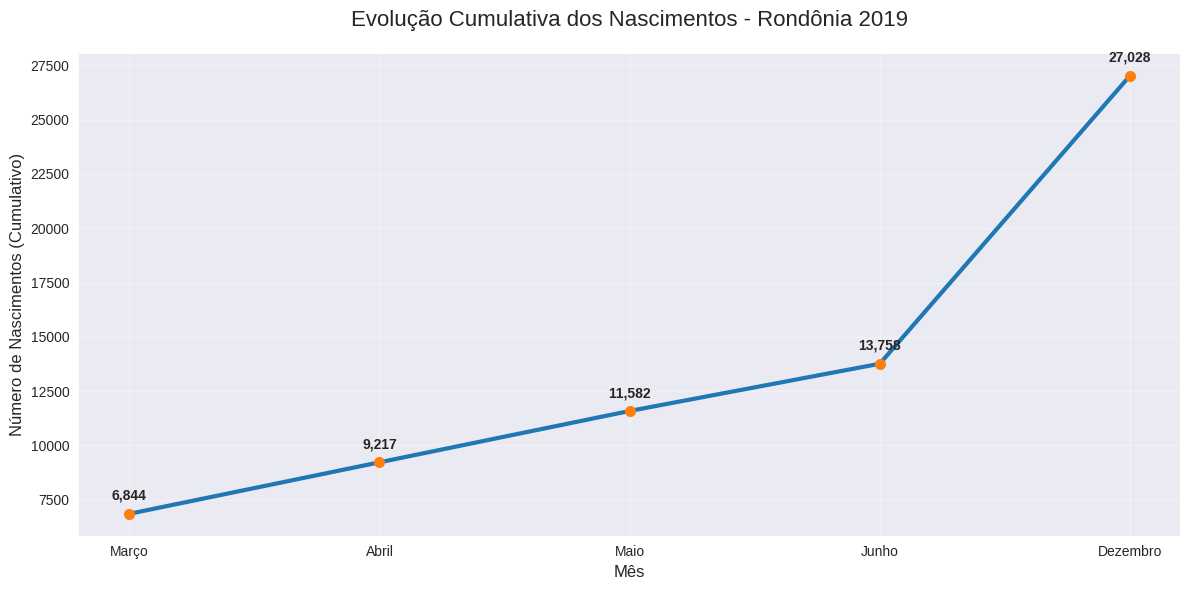

📊 Crescimento de Março para Dezembro: 20,184 nascimentos


In [4]:
# Gráfico 1: Evolução do número total de nascimentos (cumulativo)
fig = go.Figure()

meses_ordem = ['MAR', 'ABR', 'MAI', 'JUN', 'DEZ']
nascimentos = []
nomes_meses = []

for mes in meses_ordem:
    if mes in dados_meses:
        nascimentos.append(len(dados_meses[mes]))
        nomes_meses.append(meses_nomes[mes])

# Criar gráfico de linha com marcadores
fig.add_trace(go.Scatter(
    x=nomes_meses,
    y=nascimentos,
    mode='lines+markers+text',
    text=[f'{n:,}' for n in nascimentos],
    textposition='top center',
    line=dict(color='#1f77b4', width=4),
    marker=dict(size=12, color='#ff7f0e'),
    name='Nascimentos Cumulativos'
))

fig.update_layout(
    title={
        'text': '📈 Evolução Cumulativa dos Nascimentos - Rondônia 2019',
        'x': 0.5,
        'font': {'size': 18}
    },
    xaxis_title='Mês',
    yaxis_title='Número de Nascimentos (Cumulativo)',
    hovermode='x unified',
    height=500,
    template='plotly_white',
    showlegend=True
)

fig.show()

# Também criar versão estática com matplotlib
plt.figure(figsize=(12, 6))
plt.plot(nomes_meses, nascimentos, 'o-', linewidth=3, markersize=8, color='#1f77b4', markerfacecolor='#ff7f0e')
plt.title('Evolução Cumulativa dos Nascimentos - Rondônia 2019', fontsize=16, pad=20)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Número de Nascimentos (Cumulativo)', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionar valores nos pontos
for i, v in enumerate(nascimentos):
    plt.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📊 Crescimento de {nomes_meses[0]} para {nomes_meses[-1]}: {nascimentos[-1] - nascimentos[0]:,} nascimentos")

## 5. Análise de Características dos Nascimentos

In [5]:
# Gráfico 2: Distribuição por sexo ao longo dos meses
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Distribuição por Sexo', 'Peso Médio dos Bebês',
                   'Idade Média das Mães', 'Número de Consultas Pré-Natal'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Preparar dados para os gráficos
dados_graficos = {
    'meses': [],
    'masculino_pct': [],
    'feminino_pct': [],
    'peso_medio': [],
    'idade_mae_media': [],
    'consultas_media': []
}

for mes in meses_ordem:
    if mes in dados_meses:
        df = dados_meses[mes]
        dados_graficos['meses'].append(meses_nomes[mes])

        # Distribuição por sexo
        if 'SEXO' in df.columns:
            sexo_dist = df['SEXO'].value_counts(normalize=True) * 100
            dados_graficos['masculino_pct'].append(sexo_dist.get('Masculino', 0))
            dados_graficos['feminino_pct'].append(sexo_dist.get('Feminino', 0))
        else:
            dados_graficos['masculino_pct'].append(0)
            dados_graficos['feminino_pct'].append(0)

        # Peso médio
        dados_graficos['peso_medio'].append(df['PESO'].mean() if 'PESO' in df.columns else 0)

        # Idade média das mães
        dados_graficos['idade_mae_media'].append(df['IDADEMAE'].mean() if 'IDADEMAE' in df.columns else 0)

        # Consultas médias
        dados_graficos['consultas_media'].append(df['CONSULTAS'].mean() if 'CONSULTAS' in df.columns else 0)

# Gráfico de barras - Distribuição por sexo
fig.add_trace(
    go.Bar(x=dados_graficos['meses'], y=dados_graficos['masculino_pct'],
           name='Masculino', marker_color='lightblue'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=dados_graficos['meses'], y=dados_graficos['feminino_pct'],
           name='Feminino', marker_color='pink'),
    row=1, col=1
)

# Linha - Peso médio
fig.add_trace(
    go.Scatter(x=dados_graficos['meses'], y=dados_graficos['peso_medio'],
               mode='lines+markers', name='Peso (g)', line=dict(color='green')),
    row=1, col=2
)

# Linha - Idade média das mães
fig.add_trace(
    go.Scatter(x=dados_graficos['meses'], y=dados_graficos['idade_mae_media'],
               mode='lines+markers', name='Idade (anos)', line=dict(color='purple')),
    row=2, col=1
)

# Linha - Consultas médias
fig.add_trace(
    go.Scatter(x=dados_graficos['meses'], y=dados_graficos['consultas_media'],
               mode='lines+markers', name='Consultas', line=dict(color='orange')),
    row=2, col=2
)

fig.update_layout(
    title={
        'text': '👶 Análise Multidimensional dos Nascimentos por Período',
        'x': 0.5,
        'font': {'size': 16}
    },
    height=600,
    showlegend=True,
    template='plotly_white'
)

# Atualizar eixos
fig.update_yaxes(title_text="Percentual (%)", row=1, col=1)
fig.update_yaxes(title_text="Peso (gramas)", row=1, col=2)
fig.update_yaxes(title_text="Idade (anos)", row=2, col=1)
fig.update_yaxes(title_text="Nº Consultas", row=2, col=2)

fig.show()

## 6. Análise da Escolaridade das Mães e Duração da Gestação

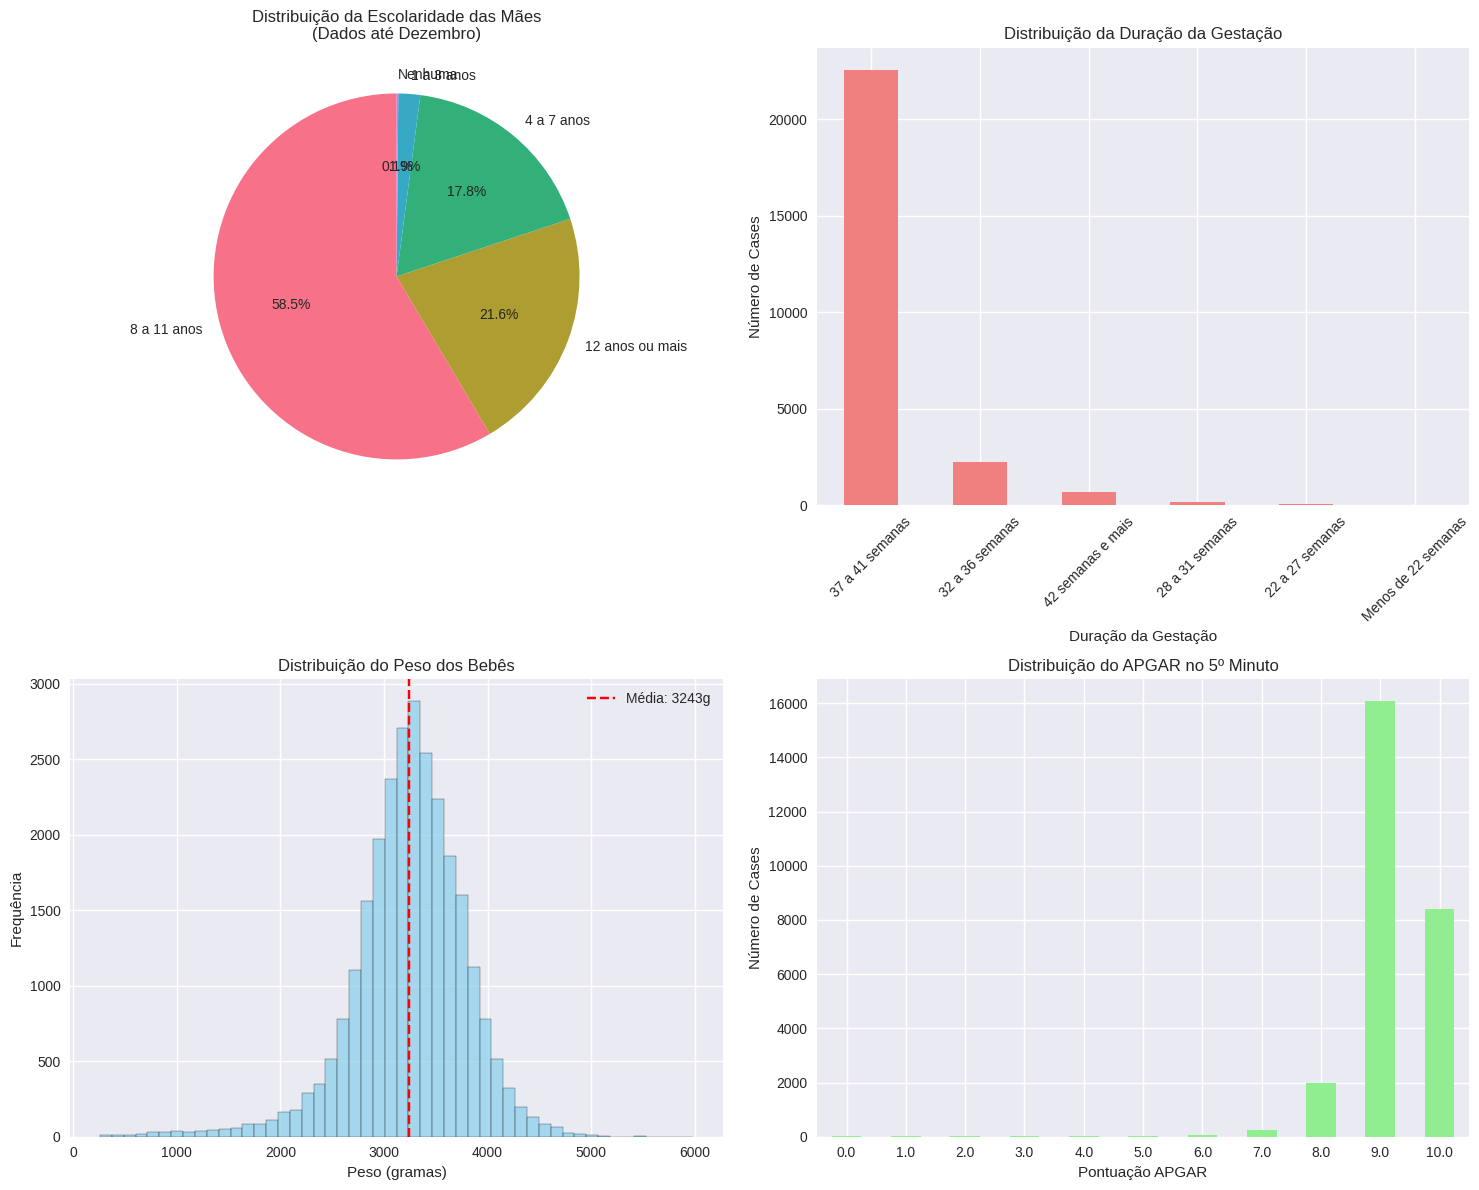

📊 ESTATÍSTICAS DESCRITIVAS (até Dezembro 2019)
Total de nascimentos: 27,028
Peso médio: 3243.2g
Peso mínimo: 258g
Peso máximo: 5985g
Idade média das mães: 26.1 anos
Média de consultas pré-natal: 3.6


In [6]:
# Análise da escolaridade das mães e gestação
# Usar dados de dezembro (mais completo) para análise detalhada
if 'DEZ' in dados_meses:
    df_dez = dados_meses['DEZ']

    # Criar subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Gráfico 1: Escolaridade das mães
    if 'ESCMAE' in df_dez.columns:
        escolaridade = df_dez['ESCMAE'].value_counts()
        axes[0, 0].pie(escolaridade.values, labels=escolaridade.index, autopct='%1.1f%%',
                       startangle=90, colors=sns.color_palette("husl", len(escolaridade)))
        axes[0, 0].set_title('Distribuição da Escolaridade das Mães\n(Dados até Dezembro)', fontsize=12)

    # Gráfico 2: Duração da gestação
    if 'GESTACAO' in df_dez.columns:
        gestacao = df_dez['GESTACAO'].value_counts()
        gestacao.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
        axes[0, 1].set_title('Distribuição da Duração da Gestação', fontsize=12)
        axes[0, 1].set_xlabel('Duração da Gestação')
        axes[0, 1].set_ylabel('Número de Cases')
        axes[0, 1].tick_params(axis='x', rotation=45)

    # Gráfico 3: Distribuição do peso dos bebês
    if 'PESO' in df_dez.columns:
        df_dez['PESO'].hist(bins=50, ax=axes[1, 0], color='skyblue', alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Distribuição do Peso dos Bebês', fontsize=12)
        axes[1, 0].set_xlabel('Peso (gramas)')
        axes[1, 0].set_ylabel('Frequência')
        axes[1, 0].axvline(df_dez['PESO'].mean(), color='red', linestyle='--',
                          label=f'Média: {df_dez["PESO"].mean():.0f}g')
        axes[1, 0].legend()

    # Gráfico 4: APGAR 5 minutos
    if 'APGAR5' in df_dez.columns:
        apgar5 = df_dez['APGAR5'].value_counts().sort_index()
        apgar5.plot(kind='bar', ax=axes[1, 1], color='lightgreen')
        axes[1, 1].set_title('Distribuição do APGAR no 5º Minuto', fontsize=12)
        axes[1, 1].set_xlabel('Pontuação APGAR')
        axes[1, 1].set_ylabel('Número de Cases')
        axes[1, 1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # Estatísticas descritivas
    print("📊 ESTATÍSTICAS DESCRITIVAS (até Dezembro 2019)")
    print("=" * 55)
    print(f"Total de nascimentos: {len(df_dez):,}")
    if 'PESO' in df_dez.columns:
        print(f"Peso médio: {df_dez['PESO'].mean():.1f}g")
        print(f"Peso mínimo: {df_dez['PESO'].min()}g")
        print(f"Peso máximo: {df_dez['PESO'].max()}g")
    if 'IDADEMAE' in df_dez.columns:
        print(f"Idade média das mães: {df_dez['IDADEMAE'].mean():.1f} anos")
    if 'CONSULTAS' in df_dez.columns:
        print(f"Média de consultas pré-natal: {df_dez['CONSULTAS'].mean():.1f}")
else:
    print("⚠️ Dados de dezembro não encontrados para análise detalhada")

## 7. Comparação Mensal com Dados Incrementais

In [7]:
# Calcular nascimentos incrementais (por mês individual)
nascimentos_incrementais = []
nascimentos_acumulados = []
meses_labels = []

anterior = 0
for i, mes in enumerate(meses_ordem):
    if mes in dados_meses:
        atual = len(dados_meses[mes])
        incremental = atual - anterior

        nascimentos_incrementais.append(incremental)
        nascimentos_acumulados.append(atual)
        meses_labels.append(meses_nomes[mes])

        anterior = atual

# Criar gráfico comparativo
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Nascimentos por Mês (Incremental)', 'Evolução Cumulativa'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}]]
)

# Gráfico de barras - Incremental
fig.add_trace(
    go.Bar(x=meses_labels, y=nascimentos_incrementais,
           name='Nascimentos/Mês',
           marker_color=['lightblue', 'lightgreen', 'lightcoral', 'gold', 'plum'],
           text=[f'{n:,}' for n in nascimentos_incrementais],
           textposition='outside'),
    row=1, col=1
)

# Gráfico de linha - Cumulativo
fig.add_trace(
    go.Scatter(x=meses_labels, y=nascimentos_acumulados,
               mode='lines+markers+text', name='Cumulativo',
               line=dict(color='darkblue', width=3),
               marker=dict(size=10, color='red'),
               text=[f'{n:,}' for n in nascimentos_acumulados],
               textposition='top center'),
    row=1, col=2
)

fig.update_layout(
    title={
        'text': '📈 Análise Temporal Completa - Nascimentos RO 2019',
        'x': 0.5,
        'font': {'size': 16}
    },
    height=400,
    template='plotly_white',
    showlegend=False
)

fig.update_yaxes(title_text="Nascimentos", row=1, col=1)
fig.update_yaxes(title_text="Total Acumulado", row=1, col=2)

fig.show()

# Imprimir resumo
print("\n📋 RESUMO DOS NASCIMENTOS POR PERÍODO")
print("=" * 45)
for i, mes in enumerate(meses_labels):
    print(f"{mes:12}: {nascimentos_incrementais[i]:,} nascimentos | Acumulado: {nascimentos_acumulados[i]:,}")

print(f"\n🏆 Mês com mais nascimentos: {meses_labels[np.argmax(nascimentos_incrementais)]} ({max(nascimentos_incrementais):,} nascimentos)")
print(f"📊 Total do ano (até dezembro): {nascimentos_acumulados[-1]:,} nascimentos")


📋 RESUMO DOS NASCIMENTOS POR PERÍODO
Março       : 6,844 nascimentos | Acumulado: 6,844
Abril       : 2,373 nascimentos | Acumulado: 9,217
Maio        : 2,365 nascimentos | Acumulado: 11,582
Junho       : 2,176 nascimentos | Acumulado: 13,758
Dezembro    : 13,270 nascimentos | Acumulado: 27,028

🏆 Mês com mais nascimentos: Dezembro (13,270 nascimentos)
📊 Total do ano (até dezembro): 27,028 nascimentos


## 8. Estratégias de Automação para Análises Futuras

### Como automatizar a geração de gráficos para novos meses/anos:

### 🚀 **Estratégias de Automação para Análises Futuras**

Para automatizar a geração de gráficos para novos meses/anos seguintes, as seguintes abordagens seriam eficazes:

#### **1. Estruturação de Dados e Configuração**
- **Padronização de nomenclatura**: Manter padrão consistente nos nomes dos arquivos (ex: `SINASC_UF_YYYY_MES.csv`)
- **Arquivo de configuração**: Criar arquivo JSON/YAML com:
  - Mapeamento de códigos de meses para nomes
  - Caminhos de diretórios
  - Parâmetros de visualização (cores, estilos)
  - Métricas a serem calculadas

#### **2. Funções Modulares e Reutilizáveis**
```python
def gerar_relatorio_automatico(ano, meses_lista, estado='RO'):
    """Função principal para gerar relatório completo"""
    # Descoberta automática de arquivos
    # Carregamento de dados
    # Geração de gráficos
    # Exportação de relatório
```

#### **3. Descoberta Automática de Arquivos**
- Usar `glob.glob()` para encontrar automaticamente arquivos novos
- Detectar periodicidade (mensal/anual) dos dados
- Validação automática da estrutura dos dados

#### **4. Pipeline de Processamento**
- **Ingestão**: Detectar e carregar novos arquivos automaticamente
- **Validação**: Verificar integridade e completude dos dados
- **Processamento**: Limpeza e transformação padronizadas
- **Visualização**: Geração automática usando templates
- **Notificação**: Alertas sobre anomalias ou dados faltantes

#### **5. Templates de Visualização**
- Criar classe `VisualizadorSINASC` com métodos para cada tipo de gráfico
- Templates Plotly/Matplotlib parametrizáveis
- Sistema de temas visuais configuráveis

#### **6. Monitoramento e Controle de Qualidade**
- Verificações automáticas de consistência temporal
- Detecção de outliers e anomalias
- Métricas de qualidade dos dados
- Logs detalhados de processamento

#### **7. Integração e Deployment**
- **Scheduler**: Executar automaticamente (cron, Apache Airflow)
- **Containerização**: Docker para ambiente reproduzível
- **Versionamento**: Git para controle de versões dos scripts
- **Dashboard**: Streamlit/Dash para interface web

#### **8. Exportação e Distribuição**
- Geração automática de PDFs com relatórios
- Dashboard interativo atualizado automaticamente
- APIs para acesso programático aos dados processados
- Integração com sistemas de BI

#### **Exemplo de Implementação:**
```python
class AutomacaoSINASC:
    def __init__(self, config_path):
        self.config = self.load_config(config_path)
        
    def descobrir_novos_dados(self):
        # Varredura automática por novos arquivos
        
    def processar_periodo(self, inicio, fim):
        # Processamento automático de um período
        
    def gerar_dashboard(self):
        # Criação de dashboard atualizado
        
    def agendar_execucao(self):
        # Configuração de execução periódica
```

Esta estrutura permitiria adicionar novos meses/anos com **mínima intervenção manual**, mantendo consistência e qualidade nas análises.